Assignment - Final - Task 4 - Classification
=================================

Please refer to ReadMe.txt for general rules for this final assignment.

In this task, you shall train and compare classification models for various versions of data.
For each of these you shall use the provided code to generate your train and test data.
Keep the images small - 32 pixels - with a single object of one of the four categories with max size 24 pixels.
You can generate as many examples for the training set as you wish (10000 may be a good number).
You shall always generate 1000 examples for the test set.

Part 1:
* Generate train a test data in the original colors (with --task4 commented out in config.ini).
* Train and test a classification network over these images to classify which type of sportsball there is in the image.
* The architecture can be fairly simple, do not go for too complicated models.

Part 2:
* Generate train a test data with random colormap (with --task4 active in config.ini).
* Use the network trained in Task 1 to classify the test mixed-color data - do not do any finetuning, use it as it is.
* Use 100 mixed-color train images to finetune (re-train) the network and test it again.
* Compare and discuss the results.
* Train and test a classification network over these mixed-color images to classify the type of sportsball.
* Use the network trained here to classify the test data in the original colors (as in Part1) - do not do any finetuning, use it as it is.
* Use 100 original color train images to finetune (re-train) the network and test it again.
* Compare and discuss the results also in comparison to the previous case.

Part 3:
* Tweak the code in `data/sportballs.py` to label each image not only by the type of sportsball but also the colormap type (original, inverted, grayscale).
* Generate train a test data with random colormap (with --task4 active in config.ini) and the two types of labels - type of sportsball and type of colormap.
* Train a model which can predict both of these labels.
* Discuss the results.

You shall follow the instructions for the content of the report as explained in ReadMe.txt.
In addition, you shall:
* Discuss the results as indicated above in Parts 1-3.
* Compare and discuss the performance of all models developed in Parts 1-3 for sportsballs classification.



In [ ]:
!unzip generated_data_with_tag.zip
!unzip generated_data_without_tag.zip
!unzip generated_data_with_tag_task3.zip

In [3]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [4]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.data_frame = pd.read_csv(dataframe)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.data_frame.iloc[idx, 0] + ".png")
        image = Image.open(img_name).convert('RGB')
        label = self.data_frame.iloc[idx, 1]

        if self.transform:
            image = self.transform(image)

        return image, label

In [30]:
class CustomImageDatasetForTask3(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):

        self.data_frame = pd.read_csv(dataframe)
        self.root_dir = root_dir
        self.transform = transform
        self.colormaps = ["original", "inverted", "grayscale"]

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.data_frame.iloc[idx, 0] + ".png")
        image = Image.open(img_name).convert('RGB')
        class_label = self.data_frame.iloc[idx, 1]
        colormap_string = self.data_frame.iloc[idx, 2]
        colormap_label = self.colormaps.index(colormap_string)

        if self.transform:
            image = self.transform(image)

        return image, class_label, colormap_label

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # Output: (16, 24, 24)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Output: (16, 12, 12)

            # Second convolutional layer
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), # Output: (32, 12, 12)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Output: (32, 6, 6)

            # Third convolutional layer
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # Output: (64, 6, 6)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Output: (64, 3, 3)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 * 3 * 3, 128),  # Fully connected layer
            nn.Dropout(0.5),
            nn.ReLU(),
            nn.Linear(128, num_classes)  # Output layer
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten the features
        x = self.classifier(x)
        return x

In [7]:
# Designed for task3 as it has both labels and colomap_labels
class CNNComposite(nn.Module):
    def __init__(self, num_classes_label, num_colormap_label):
        super(CNNComposite, self).__init__()
        self.features = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),  # Output: (16, 24, 24)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Output: (16, 12, 12)

            # Second convolutional layer
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1), # Output: (32, 12, 12)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Output: (32, 6, 6)

            # Third convolutional layer
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # Output: (64, 6, 6)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Output: (64, 3, 3)
        )

        self.class_label_classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64 * 3 * 3, 128),  # Fully connected layer
            nn.ReLU(),
            nn.Linear(128, num_classes_label)  # Output layer
        )

        self.colormap_label_classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64 * 3 * 3, 128),  # Fully connected layer
            nn.ReLU(),
            nn.Linear(128, num_colormap_label)  # Output layer
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten the features
        x1 = self.class_label_classifier(x)
        x2 = self.colormap_label_classifier(x)
        return x1,x2

In [8]:
# Training the model and saving it
def train_and_save_classfier(dataframe, root_dir, plot_dict, model_name):

    classifier = CNN(4)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)


    transform = transforms.Compose([
        transforms.Resize(24),
        transforms.ToTensor(),
    ])

    # Create an instance of the CustomImageDataset
    train_dataset = CustomImageDataset(dataframe=dataframe, root_dir=root_dir, transform=transform)

    # Create a DataLoader
    train_data_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    losses = []

    for epoch in range(10):  # loop over the dataset multiple times
        running_loss = 0.0
        for i, data in enumerate(train_data_loader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_data_loader)}')
        losses.append(running_loss)

    torch.save(classifier, model_name)

    if plot_dict["save_plot"]:
        plt.figure(figsize=(10, 5))
        plt.plot(losses, label='Training Loss')
        plt.title('Training Loss Over Time')
        plt.xlabel('Iterations')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

In [9]:
# Finetuning the previously trained model
def finetune_and_save_classfier(old_model, dataframe, root_dir, plot_dict, new_model_name):

    classifier = torch.load(old_model)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=0.001)

    transform = transforms.Compose([
        transforms.Resize(24),
        transforms.ToTensor(),
    ])

    # Create an instance of the CustomImageDataset
    train_dataset = CustomImageDataset(dataframe=dataframe, root_dir=root_dir, transform=transform)

    # Create a DataLoader
    train_data_loader = DataLoader(train_dataset, batch_size=100, shuffle=False)

    losses = []

    for epoch in range(50):  # loop over the dataset multiple times
        running_loss = 0.0
        for i, data in enumerate(train_data_loader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            break

        print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_data_loader)}')
        losses.append(running_loss)

    torch.save(classifier, new_model_name)

    if plot_dict["save_plot"]:
        plt.figure(figsize=(10, 5))
        plt.plot(losses, label='Training Loss')
        plt.title('Training Loss Over Time')
        plt.xlabel('Iterations')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

In [10]:
def accuracy(model_name, dataframe, root_dir, msg):
    transform = transforms.Compose([
            transforms.Resize(24),
            transforms.ToTensor(),
        ])

    model = torch.load(model_name)

    model.eval()

    # Create an instance of the CustomImageDataset
    test_dataset = CustomImageDataset(dataframe=dataframe, root_dir=root_dir, transform=transform)

    # Create a DataLoader
    test_data_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    correct_responses = 0

    with torch.no_grad():  # No need to track gradients for test
        for i, data in enumerate(test_data_loader, 0):
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            correct_responses+=sum(predicted==labels)

    print(f"{msg}: {(correct_responses/1000)*100}")

#Part 1


Epoch 1, Loss: 0.42233056658670637
Epoch 2, Loss: 0.06555047759655327
Epoch 3, Loss: 0.040508532520240774
Epoch 4, Loss: 0.04550861456710771
Epoch 5, Loss: 0.0056886934120071895
Epoch 6, Loss: 0.0036872969711565385
Epoch 7, Loss: 0.004633331088118252
Epoch 8, Loss: 0.10235667000840087
Epoch 9, Loss: 0.007667053210136767
Epoch 10, Loss: 0.007218435297789593


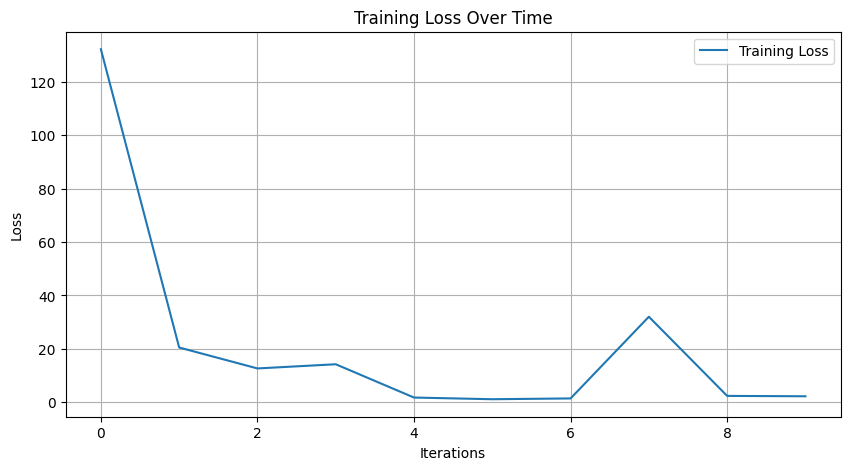

In [11]:
train_and_save_classfier(dataframe="generated_data_without_tag/Train/labels.csv",
                         root_dir="generated_data_without_tag/Train",
                         plot_dict={"save_plot":True, "plot_name":"model_without_tag"},
                         model_name="classifier_without_tag.pth")

In [12]:
accuracy(model_name="classifier_without_tag.pth",
         dataframe="generated_data_without_tag/Test/labels.csv",
         root_dir="generated_data_without_tag/Test",
         msg="Accuarcy of the model on data without tag")

Accuarcy of the model on data without tag: 99.9000015258789


#Part 2

In [13]:
# Accuracy of network trained in task1 on mixed color test images
accuracy(model_name="classifier_without_tag.pth",
         dataframe="generated_data_with_tag/Test/labels.csv",
         root_dir="generated_data_with_tag/Test",
         msg="Accuarcy of the previous model on data with tag")

Accuarcy of the previous model on data with tag: 74.9000015258789


Epoch 1, Loss: 0.21782150268554687
Epoch 2, Loss: 0.20717674255371094
Epoch 3, Loss: 0.17508943557739257
Epoch 4, Loss: 0.14470056533813477
Epoch 5, Loss: 0.12916831970214843
Epoch 6, Loss: 0.08830564498901367
Epoch 7, Loss: 0.07965933799743652
Epoch 8, Loss: 0.07036573886871338
Epoch 9, Loss: 0.05614583969116211
Epoch 10, Loss: 0.04227602481842041
Epoch 11, Loss: 0.03467767000198364
Epoch 12, Loss: 0.028768672943115234
Epoch 13, Loss: 0.024923901557922363
Epoch 14, Loss: 0.021425623893737793
Epoch 15, Loss: 0.02228142023086548
Epoch 16, Loss: 0.02121394157409668
Epoch 17, Loss: 0.01614032030105591
Epoch 18, Loss: 0.017667123079299928
Epoch 19, Loss: 0.015465220212936401
Epoch 20, Loss: 0.01583994150161743
Epoch 21, Loss: 0.013460267782211304
Epoch 22, Loss: 0.012721693515777588
Epoch 23, Loss: 0.011384701728820801
Epoch 24, Loss: 0.009230287075042724
Epoch 25, Loss: 0.009164836406707764
Epoch 26, Loss: 0.008667259216308594
Epoch 27, Loss: 0.0073596882820129396
Epoch 28, Loss: 0.007618

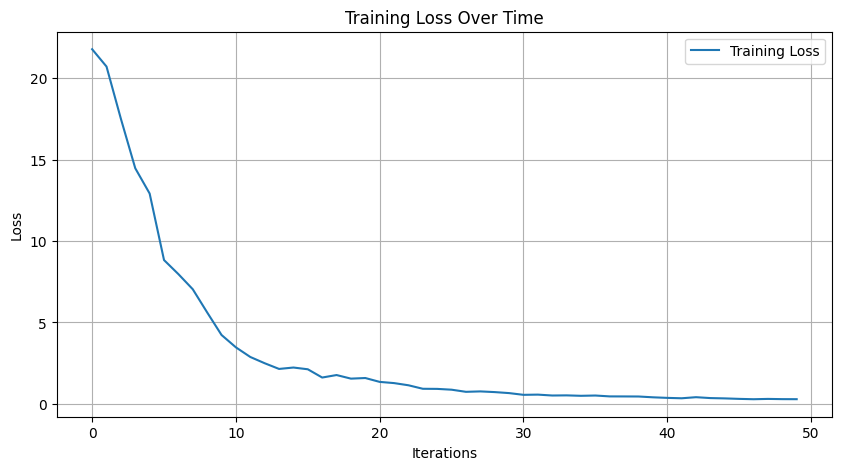

In [14]:
# finetune the task 1 model and give 100 mixed color train images
finetune_and_save_classfier(old_model="classifier_without_tag.pth",
                            dataframe="generated_data_with_tag/Train/labels.csv",
                            root_dir="generated_data_with_tag/Train",
                            plot_dict={"save_plot":True, "plot_name":"finetuned_model_without_tag_on_tag_data"},
                            new_model_name="finetuned_classifier_without_tag_on_tag_data.pth")

In [15]:
#accuracy on the finetuned model of task1 with test images of mixed colors
accuracy(model_name="finetuned_classifier_without_tag_on_tag_data.pth",
         dataframe="generated_data_with_tag/Test/labels.csv",
         root_dir="generated_data_with_tag/Test",
         msg="Accuarcy of the finetuned model without tag on data with tag")

Accuarcy of the finetuned model without tag on data with tag: 92.29999542236328


Epoch 1, Loss: 0.3603758266650902
Epoch 2, Loss: 0.022186785306857405
Epoch 3, Loss: 0.012516191435601048
Epoch 4, Loss: 0.004543302489927477
Epoch 5, Loss: 0.015178702607478079
Epoch 6, Loss: 0.016701218139249064
Epoch 7, Loss: 0.0019812281877047513
Epoch 8, Loss: 0.0005928834549553148
Epoch 9, Loss: 0.0003510266672790454
Epoch 10, Loss: 0.0018760596912191108


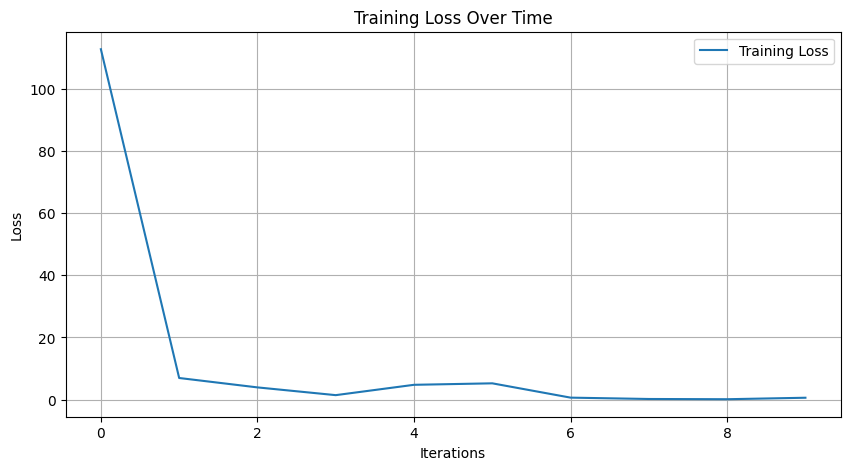

In [16]:
#train classification on data with mixed color images completely
train_and_save_classfier(dataframe="generated_data_with_tag/Train/labels.csv",
                         root_dir="generated_data_with_tag/Train",
                         plot_dict={"save_plot":True, "plot_name":"model_with_tag"},
                         model_name="classifier_with_tag.pth")

In [17]:
#accuracy of the previous model with mixed color images
accuracy(model_name="classifier_with_tag.pth",
         dataframe="generated_data_with_tag/Test/labels.csv",
         root_dir="generated_data_with_tag/Test",
         msg="Accuarcy of the model on data with tag")

Accuarcy of the model on data with tag: 99.9000015258789


In [18]:
#accuracy of the previous model with colors
accuracy(model_name="classifier_with_tag.pth",
         dataframe="generated_data_without_tag/Test/labels.csv",
         root_dir="generated_data_without_tag/Test",
         msg="Accuarcy of the model on data with tag")

Accuarcy of the model on data with tag: 99.9000015258789


Epoch 1, Loss: 1.386050098517444e-07
Epoch 2, Loss: 8.175019174814225e-06
Epoch 3, Loss: 3.626209718277096e-08
Epoch 4, Loss: 1.7556027160026134e-06
Epoch 5, Loss: 0.0006378020346164703
Epoch 6, Loss: 2.1175803340156564e-07
Epoch 7, Loss: 2.6105512915819416e-08
Epoch 8, Loss: 1.3618745470012073e-07
Epoch 9, Loss: 6.942970503587276e-07
Epoch 10, Loss: 0.00016087688505649566
Epoch 11, Loss: 0.0010694700479507446
Epoch 12, Loss: 0.00141935333609581
Epoch 13, Loss: 0.0005417661741375923
Epoch 14, Loss: 0.000438917875289917
Epoch 15, Loss: 0.00015920653939247131
Epoch 16, Loss: 4.850851371884346e-05
Epoch 17, Loss: 3.2259736326523125e-06
Epoch 18, Loss: 2.715904556680471e-06
Epoch 19, Loss: 1.3498451153282075e-06
Epoch 20, Loss: 2.8325715102255345e-05
Epoch 21, Loss: 9.363737772218884e-06
Epoch 22, Loss: 8.855619467794896e-05
Epoch 23, Loss: 3.7730965414084494e-06
Epoch 24, Loss: 8.936274680308998e-06
Epoch 25, Loss: 2.8573968447744845e-05
Epoch 26, Loss: 1.9121549557894467e-05
Epoch 27, Lo

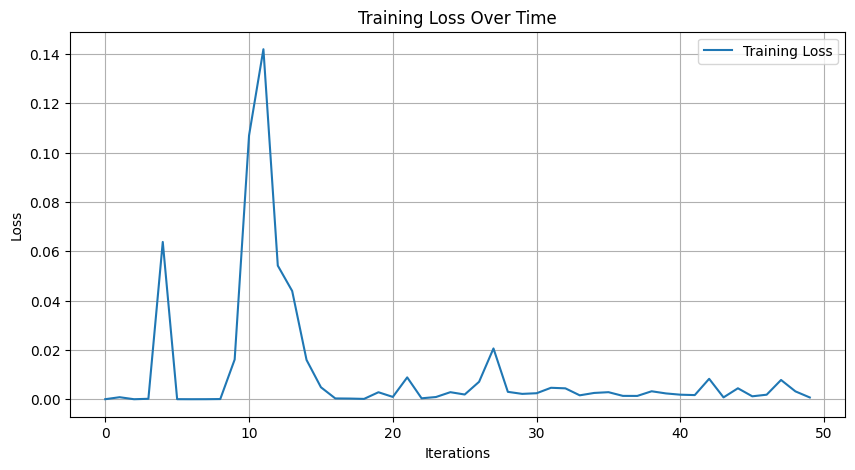

In [21]:
# 100  color train images to finetune model
finetune_and_save_classfier(old_model="classifier_with_tag.pth",
                            dataframe="generated_data_without_tag/Train/labels.csv",
                            root_dir="generated_data_without_tag/Train",
                            plot_dict={"save_plot":True, "plot_name":"finetuned_model_with_tag_on_no_tag_data"},
                            new_model_name="finetuned_classifier_with_tag_on_no_tag_data.pth")

In [22]:
# finetuned model with test color images
accuracy(model_name="finetuned_classifier_with_tag_on_no_tag_data.pth",
         dataframe="generated_data_without_tag/Test/labels.csv",
         root_dir="generated_data_without_tag/Test",
         msg="Accuarcy of the finetuned model with tag on data without tag")

Accuarcy of the finetuned model with tag on data without tag: 99.9000015258789


#Part 3

In [37]:
model = CNNComposite(num_classes_label=4, num_colormap_label=3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

transform = transforms.Compose([
    transforms.Resize(24),
    transforms.ToTensor(),
])

In [38]:
# Create an instance of the CustomImageDataset
train_dataset = CustomImageDatasetForTask3(dataframe="generated_data_with_tag_task3/Train/labels.csv",
                                            root_dir="generated_data_with_tag_task3/Train",
                                            transform=transform)

# Creating a train DataLoader
train_data_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Create an instance of the CustomImageDataset
test_dataset = CustomImageDatasetForTask3(dataframe="generated_data_with_tag_task3/Test/labels.csv",
                                          root_dir="generated_data_with_tag_task3/Test",
                                          transform=transform)

# Creating a test DataLoader
test_data_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
losses = []

for epoch in range(10):
    running_loss = 0.0
    for i, data in enumerate(train_data_loader, 0):
        inputs, class_labels, cmap_labels = data
        optimizer.zero_grad()
        outputs1, outputs2 = model(inputs)
        loss1 = criterion(outputs1, class_labels)
        loss2 = criterion(outputs2, cmap_labels)
        loss = loss1+loss2
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_data_loader)}')
    losses.append(running_loss)

Epoch 1, Loss: 1.262207785543923
Epoch 2, Loss: 0.529897083775304
Epoch 3, Loss: 0.4963818116309925
Epoch 4, Loss: 0.47027089582464565
Epoch 5, Loss: 0.4724823802043074
Epoch 6, Loss: 0.4802744631378795
Epoch 7, Loss: 0.4663852478939885
Epoch 8, Loss: 0.471608372446828
Epoch 9, Loss: 0.4662200233425957
Epoch 10, Loss: 0.5290992433270707


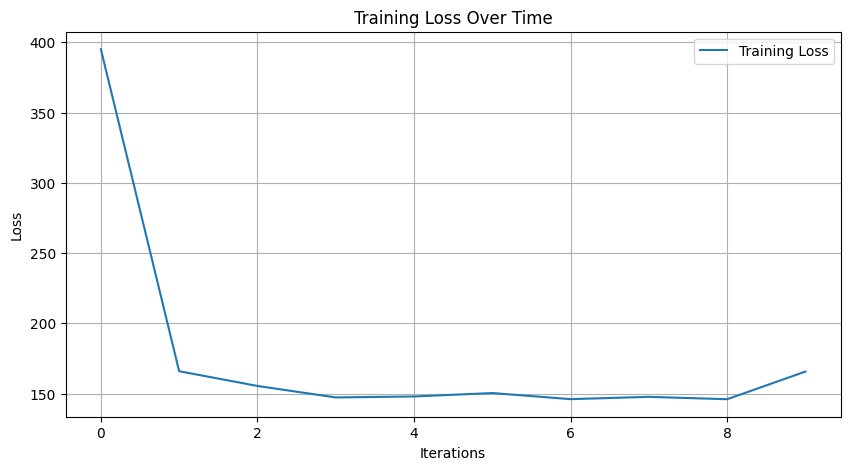

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss')
plt.title('Training Loss Over Time')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# plt.savefig("model_predicting_class_cmap_labels")
plt.show()

In [41]:
correct_responses_for_class_label = 0
correct_responses_for_cmap_label = 0

# Example: Predicting with the model
# Assuming 'inputs' is your input tensor
with torch.no_grad():  # No need to track gradients for inference
    for i, data in enumerate(test_data_loader, 0):
        inputs, class_labels, cmap_labels = data
        outputs1, outputs2 = model(inputs)
        _, predicted1 = torch.max(outputs1, 1)
        _, predicted2 = torch.max(outputs2, 1)

        correct_responses_for_class_label+=sum(predicted1==class_labels)
        correct_responses_for_cmap_label+=sum(predicted2==cmap_labels)


print(f"Accuracy in predicting class labels: {(correct_responses_for_class_label/1000)*100}")
print(f"Accuracy in predicting cmap labels: {(correct_responses_for_cmap_label/1000)*100}")

Accuracy in predicting class labels: 99.80000305175781
Accuracy in predicting cmap labels: 66.5999984741211
